In [5]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Functions

In [44]:
def p_to_stars(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

def add_stat_bracket(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=1
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=10
    )


def beautiful_boxplot(
    df_list,
    labels,
    ylabel=None,
    xlabel=None,
    title=None,
    log_scale=False,
    colors=None,         # list of colors per box (optional)
    dot_size=20,
    jitter=0.06,
    figsize=(4.8, 4.2),
    dpi=300,
    show=True,
    stat_pairs=None,
    save_path = None
):
    """
    df_list : list of pandas Series (or 1D arrays)
    labels  : list of group names (same length as df_list)
    colors  : list of colors for each box (same length as df_list) or None
    """

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Clean data
    data = [np.asarray(d.dropna()) for d in df_list]

    # Boxplot
    bp = ax.boxplot(
        data,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # Colors per box (or default)
    if colors is None:
        colors = ["lightgray"] * len(data)

    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)

    # Overlay jittered dots
    for i, y in enumerate(data, start=1):
        x = np.random.normal(loc=i, scale=jitter, size=len(y))
        ax.scatter(x, y, alpha=0.65, s=dot_size, linewidths=0)

    # Styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", length=4, width=1, labelsize=9)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=9, rotation=45, ha="right")

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    if title:
        ax.set_title(title, fontsize=11, pad=10)

    if log_scale:
        ax.set_yscale("log")
    
    if stat_pairs:
        y_max = max([np.nanmax(y) for y in data])
        y_min = min([np.nanmin(y) for y in data])
        y_range = y_max - y_min

        for idx, (x1, x2, p_value) in enumerate(stat_pairs):
            # bracket height position
            y = y_max + y_range * (0.08 + idx * 0.12)

            # bracket size
            h = y_range * 0.04

            # convert p-value to stars
            stars = p_to_stars(p_value)

            # draw bracket
            add_stat_bracket(
                ax=ax,
                x1=x1,
                x2=x2,
                y=y,
                h=h,
                text=stars
            )

        # extend ylim
        ax.set_ylim(
            top=y_max + y_range * (0.2 + len(stat_pairs) * 0.12)
        )

    fig.tight_layout()

    if show:
        plt.show()
    
    if save_path:
        fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
)

    return fig, ax

# Variables

In [27]:
# Paths to tables with data
reference_name = 'Control'  
data = [
        {'name': reference_name, 'path': "/mnt/c/users/elopatukhin/Desktop/all_WT/foci_aggregation.csv"},
        {'name': 'NC aptamer, 100 uM', 'path': "/mnt/c/users/elopatukhin/Desktop/NC_100uM/foci_aggregation.csv"},
        {'name': 'ORC1 aptamer, 100 uM', 'path': "/mnt/c/users/elopatukhin/Desktop/all_Apt3_100uM/foci_aggregation.csv"}
    ]

# Index of Control sample in the list of dictionaries 
index_control = next(
        i for i, item in enumerate(data)
        if item["name"] == "Control"
    )
    
# Path to save plot
output_dir = "/mnt/c/users/elopatukhin/Desktop/all_WT"


    
# Arguments for boxplot
args = [{
            'var': "n_foci",
            'ylabel':'Number of foci',
            'title':''
            },
            {
            'var': "sigma_nm_mean",
            'ylabel':'Sigma, nm',
            'title':''
            },
            {
            'var': "foci_MFI_mean",
            'ylabel':'Mean Fluorescent intensity of foci',
            'title':''
            }]

# Load data

In [28]:
dfs = []
for item in data:
        p = item["path"]
        df = pd.read_csv(p)
        dfs.append(df)

N_files = len(dfs)
print(f"Loaded {N_files} dataframes.")

Loaded 3 dataframes.


In [29]:
selected = [df['n_foci'] for df in dfs]

# Boxplots

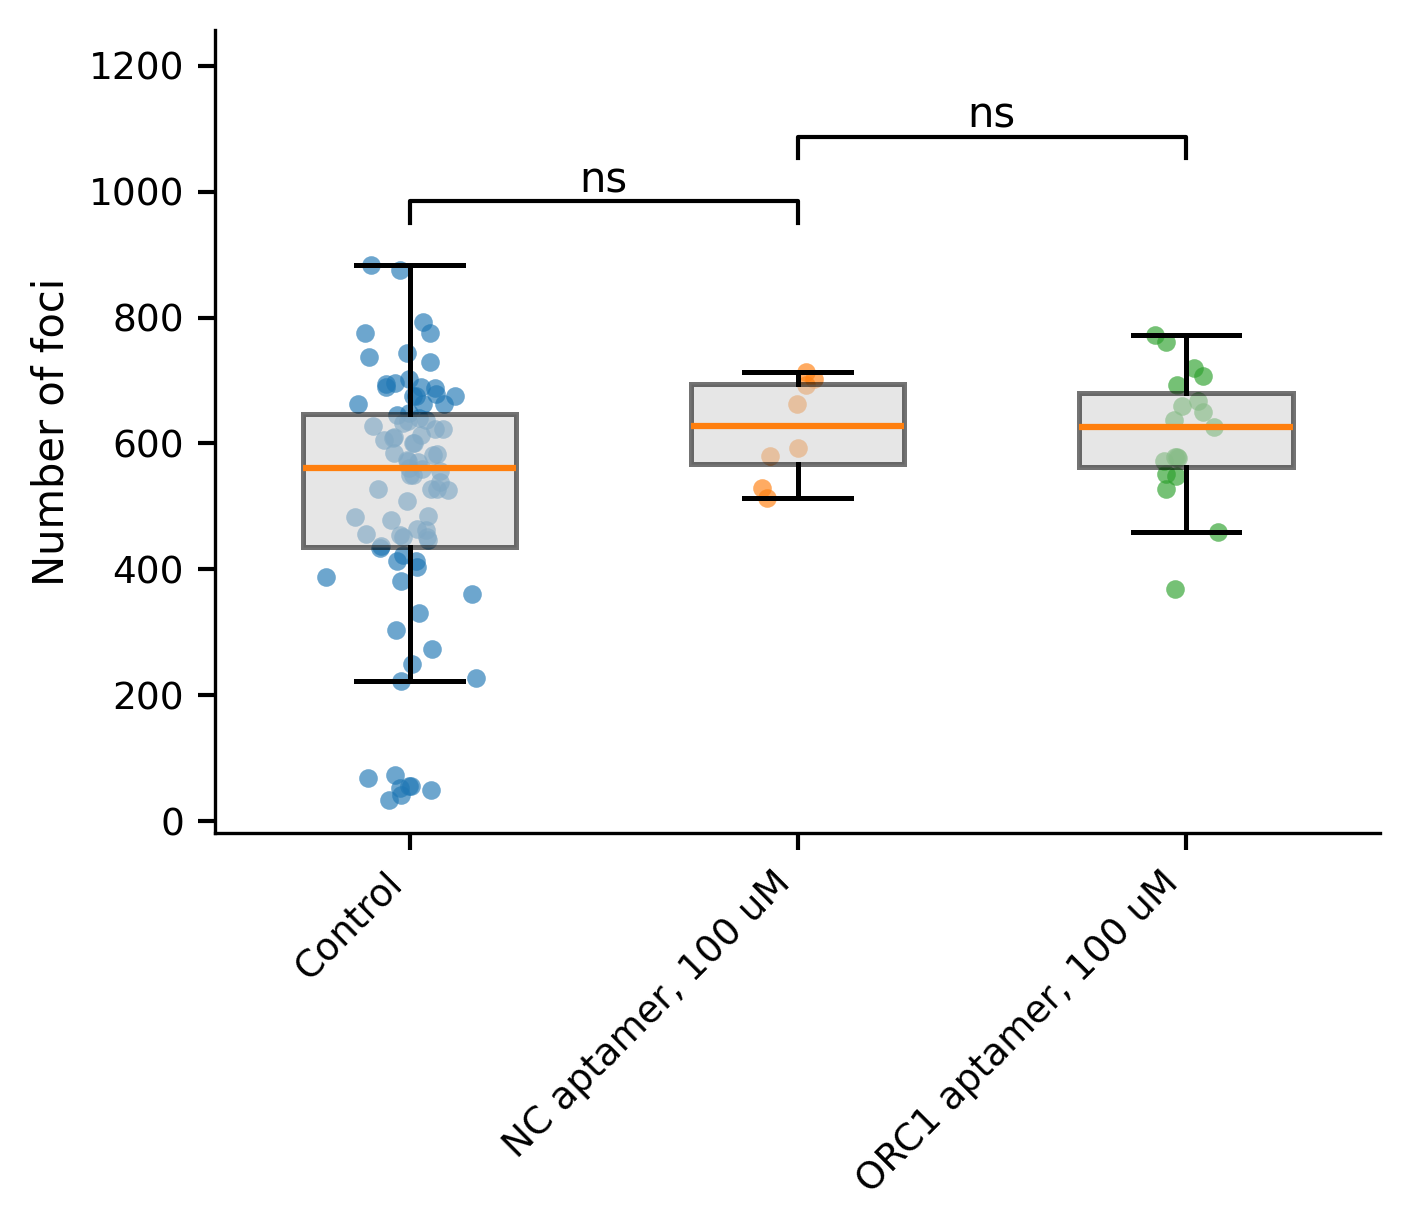

In [46]:
stat_pairs = [
    (1, 2, 0.13261493193138915),
    (2, 3, 0.8105932717485522),
]

output_dir = "/mnt/c/users/elopatukhin/Desktop/all_WT"

image = beautiful_boxplot(
    df_list = selected,
    labels = ["Control", "NC aptamer, 100 uM", "ORC1 aptamer, 100 uM"],
    ylabel="Number of foci",
    xlabel=None,
    title=None,
    log_scale=False,
    colors=None,         # list of colors per box (optional)
    dot_size=20,
    jitter=0.06,
    figsize=(4.8, 4.2),
    dpi=300,
    show=True,
    stat_pairs=stat_pairs,
    save_path = output_dir + "/plot.png"   
);

# T-test

In [23]:
t_stat, p_value = ttest_ind(selected[0], selected[1])

print("t =", t_stat)
print("p =", p_value)

t = -1.5173192585976398
p = 0.13261493193138915


In [24]:
t_stat, p_value = ttest_ind(selected[1], selected[2])

print("t =", t_stat)
print("p =", p_value)

t = 0.24221015983193436
p = 0.8105932717485522
